In [1]:
import arviz as az
from risk_experiment.utils.data import get_all_behavior
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import os.path as op
import pingouin
import scipy.stats as ss

dist = ss.norm(loc=3.5, scale=1./ss.norm().ppf(0.8) * (3.5-1))

df = get_all_behavior(bids_folder='/data/ds-risk')

/Users/gdehol/mambaforge/lib/python3.10/site-packages/nilearn/glm/__init__.py:55: FutureWarning: The nilearn.glm module is experimental. It may change in any future release of Nilearn.
  warn('The nilearn.glm module is experimental. '
100%|██████████| 30/30 [00:03<00:00,  9.65it/s]


/var/folders/d4/cpqhwlbn301clph1qk64k01nmjkty3/T/ipykernel_17105/2911551308.py:2: FutureWarning: The default value of numeric_only in DataFrameGroupBy.mean is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  tmp = df.reset_index().groupby(['subject', 'Order', 'bin(risky/safe)']).mean()
/var/folders/d4/cpqhwlbn301clph1qk64k01nmjkty3/T/ipykernel_17105/2911551308.py:21: FutureWarning: The default value of numeric_only in DataFrameGroupBy.mean is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  tmp = df.reset_index().groupby(['subject','session', 'Order', 'n_safe']).mean()


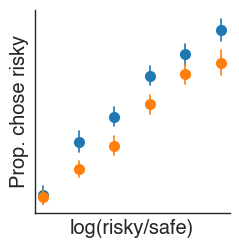

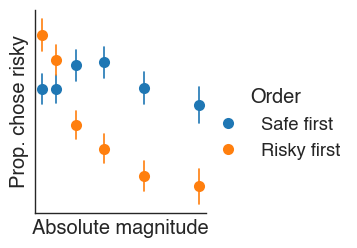

In [2]:
sns.set_theme('paper', 'white', font='helvetica', font_scale=1.5, palette='tab10')
tmp = df.reset_index().groupby(['subject', 'Order', 'bin(risky/safe)']).mean()

g = sns.FacetGrid(data=tmp.reset_index(), hue='Order', hue_order=['Safe first', 'Risky first'])
sns.despine()
# plt.ylim(0, 1)
x = np.linspace(1., 6., 50, True)


ax = g.ax
# Add the title as an annotation within the plot
# ax.plot(x, dist.cdf(x), c='k', ls='--')

g.map(sns.lineplot, 'bin(risky/safe)', 'chose_risky', marker='o', linewidth=0.0, errorbar='se', markersize=8, markeredgewidth=0, err_style='bars')
g.set_titles('')
g.set(ylabel='Prop. chose risky', xticks=[], xlabel='log(risky/safe)', yticks=[])
# g.fig.suptitle('Order effect', fontweight='bold', y=1.05)

# g.add_legend()

tmp = df.reset_index().groupby(['subject','session', 'Order', 'n_safe']).mean()

g.savefig('/data/ds-risk/derivatives/figures/order_effect_sne.pdf')

g = sns.FacetGrid(data=tmp.reset_index(), hue='Order', hue_order=['Safe first', 'Risky first'])
sns.despine()
# plt.ylim(0, 1)

# for session, ax in g.axes_dict.items():
    # Add the title as an annotation within the plot
ax = g.ax
# ax.axhline(0.5, c='k', ls='--')

g.map(sns.lineplot, 'n_safe', 'chose_risky', marker='o', linewidth=0.0, errorbar='se', markeredgewidth=0, markersize=8, err_style='bars')
g.set_titles('')
g.set(ylabel='Prop. chose risky', xticks=[], xlabel='Absolute magnitude', yticks=[])
# g.fig.suptitle('Magnitude x order effect', fontweight='bold', y=1.05)

g.add_legend()
g.savefig('/data/ds-risk/derivatives/figures/mag_order_effect_sne.pdf')

In [3]:
import os.path as op
from risk_experiment.cogmodels.fit_model import build_model, get_data
bids_folder = '/data/ds-risk'

WARNING (pytensor.tensor.blas): Using NumPy C-API based implementation for BLAS functions.


In [4]:
model_label = 'neural33'
session = None
bids_folder = '/data/ds-risk'
roi = 'npcr'

cm = 1/2.54  # centimeters in inches

data = get_data(model_label, session, bids_folder, roi)#.drop('session', axis=1)
model = build_model(model_label, data, roi)
idata = az.from_netcdf(op.join(bids_folder, 'derivatives', 'cogmodels', f'model-{model_label}_trace.netcdf'))

100%|██████████| 30/30 [00:01<00:00, 21.83it/s]


In [5]:
ppc = model.ppc(trace=idata.sel(draw=slice(None, None, 10)), data=data.drop('session', axis=1))

# "Chose risky" vs "chose 2nd option coding"
ppc.loc[ppc.index.get_level_values('risky_first')] = 1 - ppc.loc[ppc.index.get_level_values('risky_first')]


Sampling: [ll_bernoulli]


Plotting ppc type 1


/Users/gdehol/git/risk_experiment/risk_experiment/cogmodels/utils.py:66: PerformanceWarning: dropping on a non-lexsorted multi-index without a level parameter may impact performance.
  ppc = ppc.groupby(['subject']+groupby).mean()
/Users/gdehol/git/risk_experiment/risk_experiment/cogmodels/utils.py:241: FutureWarning: hdi currently interprets 2d data as (draw, shape) but this will change in a future release to (chain, draw) for coherence with other functions
  hdi = pd.DataFrame(az.hdi(ppc.T.values), index=ppc.index,
/Users/gdehol/git/risk_experiment/risk_experiment/cogmodels/utils.py:72: FutureWarning: The default value of numeric_only in DataFrameGroupBy.mean is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  p = df.groupby(groupby).mean()[['chose_risky']]


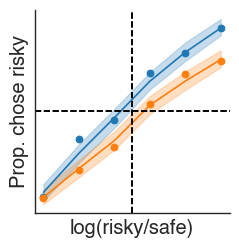

In [6]:
from risk_experiment.cogmodels.utils import plot_ppc
fac = plot_ppc(data, ppc, 1, level='group', legend=False)

# fac.fig.set_size_inches(6.4*cm, 6.4*cm)
fac.set(xlabel='log(risky/safe)', xticks=[], yticks=[])

fac.savefig('/data/ds-risk/derivatives/figures/order_effect_sne_ppc.pdf')

Plotting ppc type 2


/Users/gdehol/git/risk_experiment/risk_experiment/cogmodels/utils.py:66: FutureWarning: The default value of numeric_only in DataFrameGroupBy.mean is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  ppc = ppc.groupby(['subject']+groupby).mean()
/Users/gdehol/git/risk_experiment/risk_experiment/cogmodels/utils.py:241: FutureWarning: hdi currently interprets 2d data as (draw, shape) but this will change in a future release to (chain, draw) for coherence with other functions
  hdi = pd.DataFrame(az.hdi(ppc.T.values), index=ppc.index,
/Users/gdehol/git/risk_experiment/risk_experiment/cogmodels/utils.py:72: FutureWarning: The default value of numeric_only in DataFrameGroupBy.mean is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  p = df.groupby(groupby).mean()[['chose

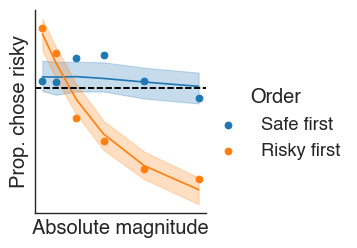

In [8]:
from risk_experiment.cogmodels.utils import plot_ppc
fac = plot_ppc(data, ppc, 2, level='group', legend=False)

# fac.fig.set_size_inches(6.4*cm, 6.4*cm)
fac.set(xlabel='Absolute magnitude', xticks=[], yticks=[])
fac.add_legend()

fac.savefig('/data/ds-risk/derivatives/figures/mag_order_effect_sne_ppc.pdf')